<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/Lessons/Module_4/Lesson_4_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 4.4 (Plague Model Continued) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1. [Learning Outcomes](#Learning-Outcomes)

2. [Introduction](#Introduction)

3. [Implementation](#Implementation)

4. [Running The Simulation](#Run)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Learning-Outcomes"></a>

---

#<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  <br>

  1. <b>Explain</b>

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

#<font size = 6> <b> 2. Introduction </b> </font>

---

##<font size = 5> <b> 2.1 Problem Recap</b> </font>

We implemented the Kermack-McKendrick (KM) model of infectious disease and used it to model a disease outbreak at Augustana. In this lesson we'll model some interventions intended to reduce the effects of the disease.

<br>

KM is an example of an *SIR model*, so-named because it divides a system (i.e. a group of people) into three categories:

<br>

-   *S*: "Susceptible" people are people who are capable of contracting the disease if they come into contact with someone who is infected.  So a "susceptible" person is not sick, and has no immunity to the infection.

-   *I*: "Infectious" people are currently sick, and so capable of passing along the disease if they come into contact with a "susceptible" person.

-   *Re*: "Recovered" people have been infected but recovered. In the basic version of the model, people who have recovered are considered to be immune to
reinfection and are not capable of infecting others.

<br>

The recovery rate $R$ denotes the average fraction of infected people recovering each time period. The contact rate $C$ deonotes the average fraction of people engaging in 'risky' contact within each time period.

<br>

We can write differential equations that describe the rates of change for the fractional population groups $s$, $i$, and $r$ as follows:

<br>

$$\frac{ds}{dt} = -C s i$$

<br>

$$\frac{di}{dt} = C s i - R i$$

<br>

$$\frac{dr}{dt} = R i$$

<br>

The code from the previous notebook is included in the cell below.

In [1]:
##=============================================================================================##
## Import Libraries:                                                                           ##
##=============================================================================================##

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display_html

In [2]:
#@title This cell defines the functions: display_dataframes, create_model, display_model, and plot_data

##=============================================================================================##
## Function:  display_dataframes                                                               ##
##                                                                                             ##
## Purpose:   Display multiple DataFrames side-by-side with titles                             ##
##                                                                                             ##
## Input(s):  dataframe_list - List of DataFrames to be displayed                              ##
##            title_list     - List of titles for the displayed DataFrames                     ##
##            n_items        - Number of items to display (optional, default = 5)              ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_dataframes(dataframe_list, title_list, n_items = 5, tail = False):

  ##===========================================================================================##
  ## Create a String for Housing the Commands to Be Sent to the display_html() Function:       ##
  ##===========================================================================================##

  html_str = ""

  ##===========================================================================================##
  ## Loop Over the Elements in the item_list and title_list:                                   ##
  ##===========================================================================================##

  for df, title in zip(dataframe_list, title_list):

    # Convert the current dataframe info to html:

    if (tail == True):

      html_df = pd.DataFrame(df).tail(n_items).to_html()

    else:

      html_df = pd.DataFrame(df).head(n_items).to_html()

    ##=========================================================================================##
    ## Wrap title and DataFrames in a Styled HTML <div>:                                       ##
    ##=========================================================================================##

    html_str += "<div style='display: inline-block; margin-right: 20px; vertical-align: top;'>"

    html_str += "<h3 style='text-align: center;'>" + str(title) + "</h3><hr>" + str(html_df)

    html_str += "</div>"

  ##===========================================================================================##
  ## Send the HTML String to the display_html() Function:                                      ##
  ##===========================================================================================##

  display_html(html_str, raw = True)

##=============================================================================================##
## Function:  create_model                                                                     ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def create_model(X, y, name, bias_on = True):

  ##===========================================================================================##
  ## Use a LinearRegression Object to Find the Best Fit for the Model:                         ##
  ##===========================================================================================##

  # Create a LinearRegression object with a forced-origin intercept:

  model = LinearRegression(fit_intercept = bias_on)

  # Fit the LinearRegression objects to the features and target:

  model.fit(X, y)

  # Get the coefficient and bias for the model:

  coefs = np.round(model.coef_[0], 2)
  bias  = np.round(model.intercept_, 2)

  ##===========================================================================================##
  ## Get The Model Predictions:                                                                ##
  ##===========================================================================================##

  predictions = model.predict(X)

  ##===========================================================================================##
  ## Calculate Model Losses:                                                                   ##
  ##===========================================================================================##

  loss = np.sqrt(mean_squared_error(y, predictions))

  ##===========================================================================================##
  ## Create a DataFrame to Store the Model's Results and Predictions:                          ##
  ##===========================================================================================##

  # Create the results DataFrame:

  results_df = pd.DataFrame({"Name": name, "Coefs": [coefs], "Bias": bias, "Loss": loss})

  # Create the predictions DataFrame:

  predictions_df = pd.DataFrame({"Target": X.iloc[:, 0]})

  predictions_df["Predictions"] = predictions

  ##===========================================================================================##
  ## Return the Model's Results and Predictions:                                               ##
  ##===========================================================================================##

  return results_df, predictions_df

##=============================================================================================##
## Function:  display_models                                                                   ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##            coef_list  - List of models' coefficients to be displayed                        ##
##            bias_list  - List of models' bias to be displayed                                ##
##            loss_list  - List of models' loss to be displayed                                ##
##            title      - Title for the display of models                                     ##
##            trunc      - Number of decimals to display for numbers (optional, default = 3)   ##
##            n_items    - Number of items to display (optional, default = 5)                  ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_model(model_list, coef_list, bias_list, loss_list, title, trunc = 3, n_items = 5):

  ##===========================================================================================##
  ## Round the Numeric Values to the Desired Level of Desired Truncation:                      ##
  ##===========================================================================================##

  for i in range (0, len(model_list)):

    coef_list[i] = np.round(coef_list[i], trunc)
    bias_list[i] = np.round(bias_list[i], trunc)
    loss_list[i] = np.round(loss_list[i], trunc)

  ##===========================================================================================##
  ## Create a DataFrame to Hold the Results:                                                   ##
  ##===========================================================================================##

  results = pd.DataFrame()

  ##===========================================================================================##
  ## Add the Contents of the DataFrame Columns:                                                ##
  ##===========================================================================================##

  # Add the model names:

  results["Model"] = model_list

  # Add the model coefficients:

  results["Coefficient(s)"] = coef_list

  # Add the model biases:

  results["Bias"] = bias_list

  # Add the model rmses:

  results["Loss"] = loss_list

  ##===========================================================================================##
  ## Index the Results DataFrame By Model Name:                                                ##
  ##===========================================================================================##

  results.set_index("Model", inplace = True)

  ##===========================================================================================##
  ## Display the Results DataFrame Using display_dataframes():                                 ##
  ##===========================================================================================##

  display_dataframes([results], [title], n_items)

##=============================================================================================##
## Function:  plot_data                                                                        ##
##                                                                                             ##
## Purpose:   Create a scatterplot with optional model overlays and error bands                ##
##                                                                                             ##
## Input(s):  x_data        - List of data points' x-axis values                               ##
##            y_data        - List of data points' y-axis values                               ##
##            title         - Graph title                                                      ##
##            axis_labels   - Override axis labels [x_label, y_label] (optional)               ##
##            model_list    - List of model predictions to overlay (optional)                  ##
##            color_list    - Colors for each model line (optional)                            ##
##            label_list    - Labels for each model line (optional)                            ##
##            error_display - Show +/- error band around first model (default is False)        ##
##            error         - Error value for shaded band (optional)                           ##
##                                                                                             ##
## Output(s): graph       - Matplotlib axes object, can be used for overplotting               ##
##=============================================================================================##

def plot_data(x_data, y_data, title, axis_labels = [], model_list = [], color_list = [],
              label_list = [], error_display = False, error = 0):

  ##===========================================================================================##
  ## Setup the Graph:                                                                          ##
  ##===========================================================================================##

  # Create the Matplotlib figure:

  figure = plt.figure(figsize = (12, 9))

  # Add a graph to the figure:

  graph = figure.add_subplot()

  # Set the graph background Color:

  graph.set_facecolor('lightcyan')

  # Set the graph title:

  graph.set_title(title, fontsize = 20)

  # Set the x_label and y_label:

  if (axis_labels != []):

    graph.set_xlabel(axis_labels[0], fontsize = 14)

    graph.set_ylabel(axis_labels[1], fontsize = 14)

  # Apply a grid to the graph:

  graph.grid(which = 'both')

  # Adjust the x-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'x', tight = False)

  # Adjust the y-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'y', tight = False)

  ##===========================================================================================##
  ## Add Data to the Graph:                                                                    ##
  ##===========================================================================================##

  # Create a scatterplot of the data:

  sns.scatterplot(x = x_data, y = y_data, ax = graph)

  # Overlay model predictions:

  for i in range(0, len(model_list)):

    graph.plot(model_list[i]["Target"], model_list[i]["Predictions"], color = color_list[i],
               label = label_list[i])

  ##===========================================================================================##
  ## If requested, show the +/- error bounds:                                                  ##
  ##===========================================================================================##

  if ((error_display == True) and model_list != []):

    # Create the error+ model:

    model_plus_error  = model_list[-1]["Predictions"] + error

    # Create the error- model:

    model_minus_error = model_list[-1]["Predictions"] - error

    # Store the error+ and error- models in a DataFrame and Sort by x_data values:

    error_df = pd.DataFrame({
        'X-Data': model_list[0]["Target"],
        'Model+Error': model_plus_error,
        'Model-Error': model_minus_error
    }).sort_values(by = "X-Data")

    # Use graph.fill to highlight the region between the error+ and error- models:

    graph.fill_between(error_df['X-Data'], error_df['Model+Error'], error_df['Model-Error'],
                       alpha = 0.5, color = (0.6, 0.6, 0.6), label = "Error Bounds")

  ##===========================================================================================##
  ## Apply the Legend and Return the graph Object:                                             ##
  ##===========================================================================================##

  # Add the graph legend:

  if (label_list != []): graph.legend()

  # Return the graph:

  return graph

In [3]:
#@title This cell sets the simulation parameters and initial state.

##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Initial Number of Susceptible People:

S_initial = 89

# Initial Number of Infectious People:

I_initial = 1

# Initial Number of Recovered People:

R_initial = 0

# Recovery Time:

t_recovery = 4 # days

# Time Between Risky Contacts (per person):

t_contact = 3 # days

# Runtime for the simulation:

t_end = 14 * 7 # 14 weeks * 7 days / week

# Time Step:

dt = 1 # day

##=============================================================================================##
## Convert the Input Parameters to Simulation Parameters:                                      ##
##=============================================================================================##

# Total Number of People in Simulation Initially:

N = S_initial + I_initial + R_initial

# Initial Fraction of Susceptible People:

s_initial = S_initial / N

# Initial Fraction of Infectious People:

i_initial = I_initial / N

# Initial Fraction of Recovered People:

r_initial = R_initial / N

# Recovery Rate:

R = 1 / t_recovery

# Risky Contact Rate:

C = 1 / t_contact

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_sir = pd.Series({
    "s_initial": s_initial,
    "i_initial": i_initial,
    "r_initial": r_initial,
    "R":         R,
    "C":         C,
    "t_end":     t_end,
    "dt":        dt
})

# Rename the columns:

parameters_sir.name = 'Value'

parameters_sir.index.name = "Parameter"

##=============================================================================================##
## Create the State Object                                                                     ##
##=============================================================================================##

initial_state_sir = pd.Series({
    "s" : parameters_sir["s_initial"],
    "i" : parameters_sir["i_initial"],
    "r" : parameters_sir["r_initial"],
    "Time"        : 0
})

initial_state_sir.name = 'SIR State'

# Display the Parameters and Initial State:

display_dataframes([parameters_sir, initial_state_sir],["Parameters SIR", "Initial State"], n_items = 10)

,Value
Parameter,
s_initial,0.988889
i_initial,0.011111
r_initial,0.000000
R,0.250000
C,0.333333
t_end,98.000000
dt,1.000000
,SIR State
s,0.988889


In [4]:
#@title This cell defines the functions: change_function, run_simulation, and analyze_simulation.

##=============================================================================================##
## Define the Change Function:                                                                 ##
##=============================================================================================##

# This function updates the s, i, and r fractions for each time step based on the system state
# and the input parameters.

def change_function(state, parameters):

  # Unpack the parameters and state:

  s = state['s']

  i = state['i']

  r = state['r']

  R = parameters['R']

  C = parameters['C']

  dt = parameters['dt']

  # Calculate the number of people infected during the current time step:

  infected = C * i * s

  # Calculate the number of people recovered during the current time step:

  recovered = R * i

  # The current fraction of susceptible people decreases by the amount infected during this time
  # step:

  s -= infected

  # The current fraction of infected people increases by the amount infected during this time step
  # and decreases by the amount of people recovered during this time step:

  i += infected - recovered

  # The current fraction of recovered people increases by the amount recovered during this time
  # step:

  r += recovered

  # Create a local copy of the state object:

  state_local = state.copy()

  # Update the susceptible fraction:

  state_local['s'] = s

  # Update the infected fraction:

  state_local['i'] = i

  # Update the recovered fraction:

  state_local['r'] = r

  # Update the time:

  state_local['Time'] += dt

  # Return the updated system state:

  return state_local

##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation(parameters, initial_state, change_function):

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Get the end time:

  end_time = parameters.loc['t_end']

  # Get the step size:

  dt = parameters.loc['dt']

  # Calculate the number of simulation steps:

  n_steps = int(end_time / dt)

  ##===========================================================================================##
  ## Create a Copy of the Initial State:                                                       ##
  ##===========================================================================================##

  state = initial_state.copy()

  ##===========================================================================================##
  ## Create the System's State History:                                                        ##
  ##===========================================================================================##

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'Populations Over Time'

  state_history.index.name = 'Time Step'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  for i in range(n_steps):

    # Get the state of the system for the current time step:

    state = change_function(state, parameters)

    # Store the new system state in the state_history DataFrame:

    state_history.loc[i + 1] = state.T

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

##=============================================================================================##
## Create a Function to Analyze the Simulation Results:                                        ##
##=============================================================================================##

def analyze_simulation(state_history, parameters, plot_data = False, display_data = False):

  ##===========================================================================================##
  ## If requested, display the history data:                                                   ##
  ##===========================================================================================##

  if (display_data == True):

    # View the system's state history and final state:

    display_dataframes([state_history],["State History"])

    print()

    print("Final State:")

    display(state_history.iloc[-1])

  ##===========================================================================================##
  ## If requested, plot the history data:                                                      ##
  ##===========================================================================================##

  if (plot_data == True):

    # Create the plot of the DataFrame:

    ax = state_history.plot(
        kind    = 'line',
        y       = ['s', 'i', 'r'],
        x       = 'Time',
        color   = ['red', 'blue', 'yellow'],
        figsize = (10, 6)
    )

    # Add titles and labels to the plot:

    ax.set_title("Populations Vs. Time", fontsize = 14)

    ax.set_xlabel("Days", fontsize = 12)

    ax.set_ylabel("Population Fraction)", fontsize = 12)

    # Add grid and legend:

    plt.grid(True, linestyle = '--', alpha=0.5)

    plt.tight_layout()

    # Display the plot:

    plt.show()

<center>$\rule$</center>

##<font size = 5> <b> 2.2 Test the Simulation </b> </font>

Let's test the simulation code and make sure that it works just as it did in the previous notebook.


Time Step,s,i,r,Time
0,0.988889,0.011111,0.000000,0.0
1,0.985226,0.011996,0.002778,1.0
2,0.981287,0.012936,0.005777,2.0
3,0.977055,0.013934,0.009011,3.0
4,0.972517,0.014988,0.012494,4.0



Final State:


,98
Time Step,
s,0.520568
i,0.000666
r,0.478766
Time,98.000000


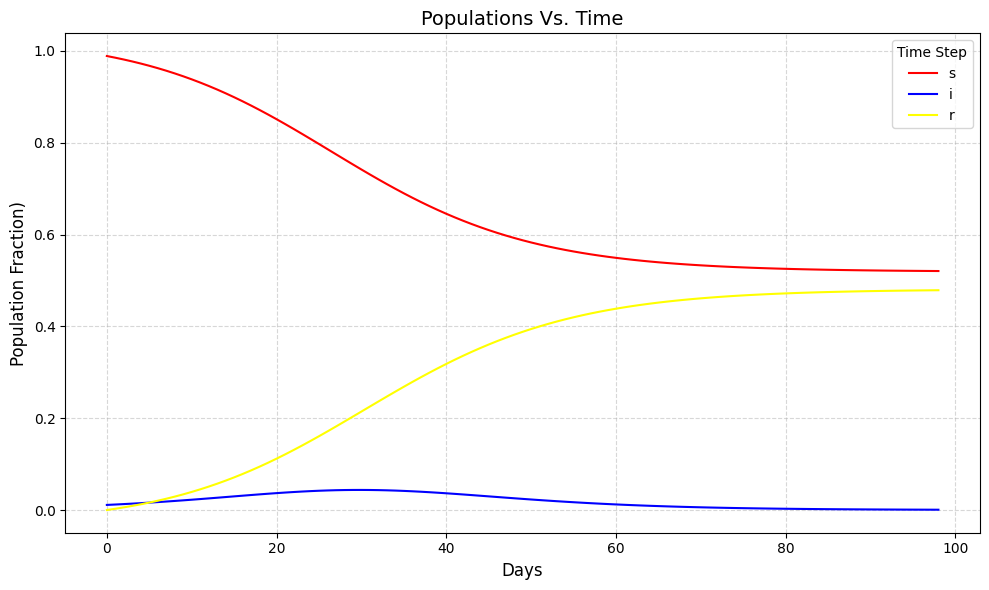

In [5]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

history_sir = run_simulation(parameters_sir, initial_state_sir, change_function)

analyze_simulation(history_sir, parameters_sir, plot_data = True, display_data = True)

Excellent! We have the same result as before, now we are ready to continue.

[Return to Top](#Notebook-Start)

<a name="Immunization"></a>

---

#<font size = 6> <b> 3. Adding Immunization </b> </font>

---

##<font size = 5> <b> 3.1 Implementing Immunization</b> </font>

Models like this are useful for testing "what if?" scenarios. As an
example, we'll consider the effect of immunization: suppose there is a vaccine that causes a student to become immune to the spreading disease without being infected. How might you modify the model to capture this effect?

<br>

One option is to treat immunization as a shortcut from susceptible to
recovered without going through infectious. We can implement this
feature like this:


In [6]:
##=============================================================================================##
## Define the Immunization Function:                                                           ##
##=============================================================================================##

def add_immunization(state, fraction):

  # Create a local copy of the state object:

  state_local = state.copy()

  # Remove the affected fraction from the susceptible fractional population.

  state_local['s'] -= fraction

  # Add the affected fraction from the recovered fractional population.

  state_local['r'] += fraction

  # Return the updated system:

  return state_local

`add_immunization` moves the given fraction of the population from `s`
to `r`. Let's see what happens if 10% of students are immune. We'll create a new initial state object that has had `add_immunization` run on it, and re-run the simulation. Once we have the results of the new simulation, we'll compare them to the simulation we ran earlier that had no immunization.

In [7]:
##=============================================================================================##
## Create the New Initial State (10% Initial Immunization):                                    ##
##=============================================================================================##

initial_state_sir_immunized = add_immunization(initial_state_sir, 0.1)

display_dataframes([initial_state_sir, initial_state_sir_immunized],
 ["No Immunization", "With Immunization"])

,SIR State
s,0.988889
i,0.011111
r,0.000000
Time,0.000000
,SIR State
s,0.888889
i,0.011111
r,0.100000
Time,0.000000


<center>$\rule$</center>

##<font size = 5> <b> 3.2 Run the Simulation With 10% Initial Immunization</b> </font>

Now that we have our new initial state (which includes 10% initial immunization), lets re-run the simulation and view the results.


Time Step,s,i,r,Time
0,0.888889,0.011111,0.100000,0.0
1,0.885597,0.011626,0.102778,1.0
2,0.882165,0.012151,0.105684,2.0
3,0.878592,0.012686,0.108722,3.0
4,0.874876,0.013230,0.111893,4.0



Final State:


,98
Time Step,
s,0.582381
i,0.001387
r,0.416232
Time,98.000000


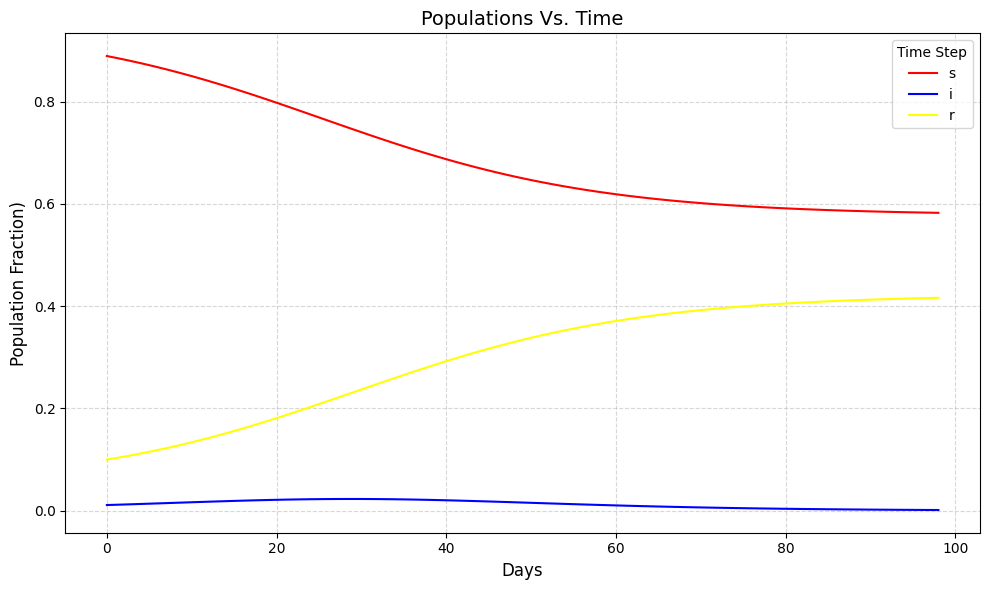

Time Step,s,i,r,Time
98,0.520568,0.000666,0.478766,98.0
Time Step,s,i,r,Time
98,0.582381,0.001387,0.416232,98.0


In [8]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

history_sir_imm_10 = run_simulation(parameters_sir, initial_state_sir_immunized, change_function)

analyze_simulation(history_sir_imm_10, parameters_sir, plot_data = True, display_data = True)

display_dataframes([history_sir, history_sir_imm_10], ["No Immunization", "10% Immunization"],
                   n_items = 1, tail = True)

We see that with immunization, there is a smaller change in `s`; that is, fewer people are infected. In the next section we'll compute this change and use it to quantify the effect of immunization.

<center>$\rule$</center>

##<font size = 5> <b> 3.3 Deciding on A Metric</b> </font>

When we plot the History, we get a view of everything that happened
when the model ran, but often we want to boil it down to a few numbers
that summarize the outcome. That is, we want a <b>metric</b>.

<br>

In the KM model, we might want to know the time until the peak of the
outbreak, the number of people who are sick at the peak, the number of
students who will still be sick at the end of the semester, or the total number of students who get sick at any point.

<br>

As an example, we will focus on the last one --- the total number of sick students --- as we consider interventions intended to minimize it. We can get the total number of infections by computing the difference in `s` at the beginning and the end of the simulation.

In [9]:
##=============================================================================================##
## Define the Total Infected Function:                                                         ##
##=============================================================================================##

def total_infected(history):

  # Get the initial value of the susceptible fraction:

  s_initial = history.iloc[0]['s']

  # Get the final value of the susceptible fraction:

  s_end = history.iloc[-1]['s']

  # The difference is the fraction of the population who were infected:

  infected_fraction = s_initial - s_end

  # Return the result:

  return infected_fraction

Now we compute the results from the two simulations.

In [10]:
##=============================================================================================##
## Get the Total Infected Fraction From Each Simulation:                                       ##
##=============================================================================================##

total_infected_no_imm = total_infected(history_sir)

total_infected_10_imm = total_infected(history_sir_imm_10)

print("Total Infected (No Immunization):", np.round(total_infected_no_imm * 100, 2), "%")
print()
print("Total Infected (10% Immunization):", np.round(total_infected_10_imm * 100, 2), "%")

Total Infected (No Immunization): 46.83 %

Total Infected (10% Immunization): 30.65 %


Without immunization, almost 47% of the population gets infected at some point. With 10% immunization, only 31% get infected. That's pretty good: notice that an additional 6% of students do not get infected even though they were not actually immunized!

<center>$\rule$</center>

##<font size = 5> <b> 3.4 Sweeping the Immunization Parameter</b> </font>

Now let's see what happens if we administer more vaccines. This following function sweeps a range of immunization rates:

In [11]:
##=============================================================================================##
## Define the Sweep Immunity Function:                                                         ##
##=============================================================================================##

def sweep_immunity(state_base, fraction_array):

  # Create an empty DataFrame to store the percent infected for each of the simulations:

  total_infected_series = pd.Series([],dtype=object)

  # Create a copy of the supplied base state so as not to overwrite any of its values:

  state_base_local = state_base.copy()

  # Loop over the values in the supplied fraction array for initial immunization:

  for fraction in fraction_array:

    # Create the initial state based on the current immunization percentage:

    initial_state = add_immunization(state_base_local, fraction)

    # Run the simulation with the current initial state:

    history = run_simulation(parameters_sir, initial_state, change_function)

    # Get the total infected fraction from the simulation:

    total_infected_fraction = total_infected(history)

    # Store the total infected fraction in the series:

    total_infected_series[fraction] = total_infected_fraction

  # Organize the total infected series:

  total_infected_df = pd.DataFrame(total_infected_series)

  total_infected_df.columns = ['Total Infected']

  total_infected_df.index.name = 'Fraction Immunized'

  total_infected_df.reset_index(inplace = True)

  # Return the total infected series:

  return total_infected_df

The inputs to `sweep_immunity` are the original initial state and an array of immunization rates. The result is a `Series` object that maps from each immunization rate to the resulting fraction of students ever infected.

We can call it like this:

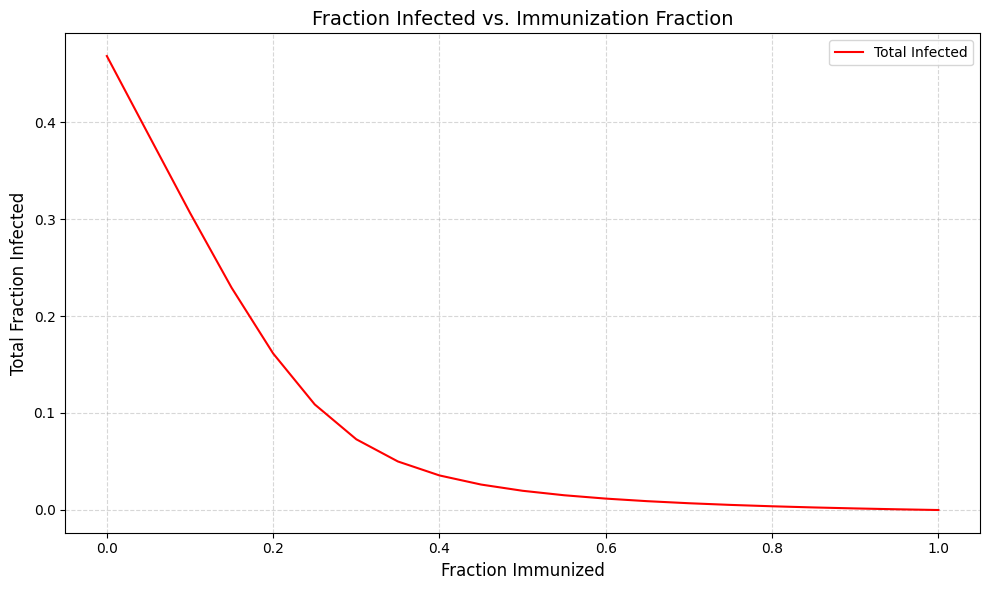

In [12]:
##=============================================================================================##
## Create the Array of Immunization Fractions:                                                 ##
##=============================================================================================##

fraction_array = np.linspace(0, 1, 21)

##=============================================================================================##
## Run the Parameter Sweep:                                                                    ##
##=============================================================================================##

infected_sweep = sweep_immunity(initial_state_sir, fraction_array)

##=============================================================================================##
## Graph the Results:                                                                          ##
##=============================================================================================##

ax = infected_sweep.plot(
    kind    = 'line',
    y       = ['Total Infected'],
    x       = 'Fraction Immunized',
    color   = ['red'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Fraction Infected vs. Immunization Fraction", fontsize = 14)

ax.set_xlabel("Fraction Immunized", fontsize = 12)

ax.set_ylabel("Total Fraction Infected", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha=0.5)

plt.tight_layout()

# Display the plot:

plt.show()

As the immunization rate increases, the number of infections drops
steeply. If 40% of the students are immunized, fewer than 4% get sick.  That's because immunization has two effects: it protects the people who get immunized (of course) but it also protects the rest of the
population.

<br>

Reducing the number of "susceptibles" and increasing the number of
"resistants" makes it harder for the disease to spread, because some
fraction of contacts are wasted on people who cannot be infected. This phenomenon is called *herd immunity*, and it is an important element
of public health.

<br>

The steepness of the curve is a blessing and a curse. It's a blessing
because it means we don't have to immunize everyone, and vaccines can
protect the "herd" even if they are not 100% effective.  But it's a curse because a small decrease in immunization can cause a
big increase in infections. In this example, if we drop from 80%
immunization to 60%, that might not be too bad. But if we drop from 40% to 20%, that would trigger a major outbreak, affecting more than 15% of the population. For a serious disease like measles, just to name one, that would be a public health catastrophe.

[Return to Top](#Notebook-Start)

<a name="HandWashing"></a>

---

#<font size = 6> <b> 4. Hand Washing Campaign </b> </font>

---

##<font size = 5> <b> 4.1 The Set Up</b> </font>

Suppose you are the Dean of Student Life, and you have a budget of just \$1200 to combat the outbreak. You have two options for spending this money:

1.  You can pay for vaccinations, at a rate of \$100 per dose.

2.  You can spend money on a campaign to remind students to wash hands
    frequently.

We have already seen how we can model the effect of vaccination. Now
let's think about the hand-washing campaign. We'll have to answer two
questions:

1.  How should we incorporate the effect of hand washing in the model?

2.  How should we quantify the effect of the money we spend on a
    hand-washing campaign?

For the sake of simplicity, let's assume that we have data from a
similar campaign at another school showing that a well-funded campaign
can change student behavior enough to reduce the infection rate by 20%.

<br>

In terms of the model, hand washing has the effect of reducing `C`: because students are less likely to infect others, then we assume there are fewer contacts between students that could result in infection.
That's not the only way we could incorporate the effect, but it seems
reasonable and it's easy to implement.

<br>

Now we have to model the relationship between the money we spend and the
effectiveness of the campaign. Again, let's suppose we have data from
another school that suggests:

-   If we spend \$500 on posters, materials, and staff time, we can
    change student behavior in a way that decreases the effective value of `C` by 10%.

-   If we spend \$1000, the total decrease in `C` is almost 20%.

-   Above \$1000, additional spending has little additional benefit.

<center>$\rule$</center>

##<font size = 5> <b> 4.2 Choosing a function to model benefits of hand-washing </b> </font>

We have made an assumption that spending more money on a hand-washing campaign will decrease `C`.   But we need to define that relationship: how much does each new dollar spent change the parameter?

<br>

As with other modeling decisions, this one requires that we make some assumptions (see the assumptions in the previous cell, for instance).  Our function just quantizes these assumptions.   We could assume a linear function: each dollar increases `C` by a given amount, until we reach 1000 dollars.  This function would look like this, where `D` is the number of dollars spent and $\Delta \beta$ is the change in `C`:

<br>

$$\text{If } D < 1000\text{, } \Delta C\of{D} = (0.20D)/1000$$

<br>

$$ \text{If } D  >= 1000\text{, } \Delta C\of{D} = 0.20$$

<br>

But let's use a model that fits our intuition better.   Let's assume that spending a couple dollars would have little benefit: that is, benefits wouldn't really occur until you spent at least a couple hundred dollars.  And further, let's assume that the benefit would gradually decrease as spending approached \$1000.

<br>

One possible function that fits this description is a [generalized logistic function](https://en.wikipedia.org/wiki/Generalised_logistic_function) (GLF), which is a convenient function for modeling curves that have a generally sigmoid shape.  The parameters of the GLF correspond to various features of the curve in a way that makes it easy to find a function that has the shape you want, based on data or background information about the scenario.  Here's a python function that creates a logistic curve:

In [13]:
##=============================================================================================##
## Import the EXP function from Numpy:                                                         ##
##=============================================================================================##

from numpy import exp

##=============================================================================================##
## Define a Generalized Logistic Function:                                                     ##
##=============================================================================================##

def logistic(x, A=0, B=1, C=1, M=0, K=1, Q=1, nu=1):

  # Computes the generalize logistic function.
  #
  # A: controls the lower bound
  # B: controls the steepness of the transition
  # C: not all that useful, AFAIK
  # M: controls the location of the transition
  # K: controls the upper bound
  # Q: shift the transition left or right
  # nu: affects the symmetry of the transition
  #
  # returns: float or array

  exponent = -B * (x - M)
  denom = C + Q * exp(exponent)

  return A + (K-A) / denom ** (1/nu)

Now we need a function that creates the particular logistic function that we want.  We can choose the parameters to fit our assumptions about the effects of spending money on hand-washing:

`M` is chosen so the transition happens around \$500.

`K` is the maximum reduction in `C`, 20\%.

`B` is chosen by trial and error to yield a curve that seems feasible.

`compute_factor` computes the reduction in `C` for a given level of campaign spending.  It will return a `C` reduction from 0\% to 20\% based upon the level of spending:

In [14]:
##=============================================================================================##
## Define the Compute Factor Function:                                                         ##
##=============================================================================================##

def compute_factor(spending):

  # Reduction factor as a function of spending.
  #
  # spending: dollars from 0 to 1200
  #
  # returns: fractional reduction in C

  return logistic(spending, M = 500, K = 0.2, B = 0.01)

Let's see what our curve looks like.  We create a `linspace` of possible spending amounts from 0 to 1200 dollars, convert our array to a percent, and then plot it:

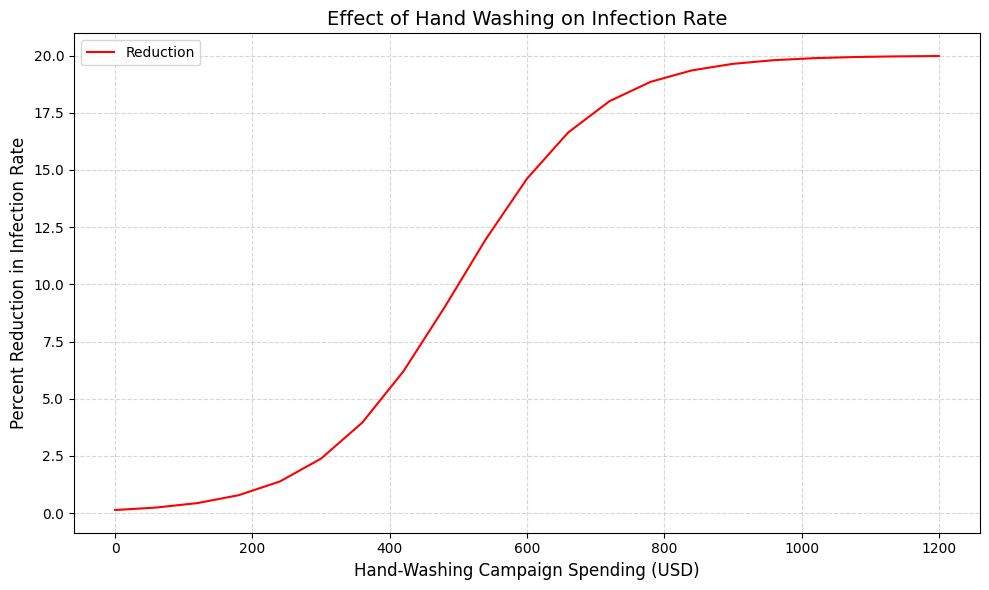

In [15]:
##=============================================================================================##
## Create an Array of Spending Values:                                                         ##
##=============================================================================================##

spending = np.linspace(0, 1200, 21)

##=============================================================================================##
## Compute the Reduction in C for Each Spending Value:                                         ##
##=============================================================================================##

percent_reduction = compute_factor(spending) * 100

##=============================================================================================##
## Plot the Result:                                                                            ##
##=============================================================================================##

spend_vs_reduce = pd.DataFrame({"Reduction" : percent_reduction, "Spending" : spending})

ax = spend_vs_reduce.plot(
    kind    = 'line',
    y       = ['Reduction'],
    x       = 'Spending',
    color   = ['red'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Effect of Hand Washing on Infection Rate", fontsize = 14)

ax.set_xlabel("Hand-Washing Campaign Spending (USD)", fontsize = 12)

ax.set_ylabel("Percent Reduction in Infection Rate", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha=0.5)

plt.tight_layout()

# Display the plot:

plt.show()

Now we need to use `compute_factor` to change the `C` for a particular simulation.

`add_hand_washing` takes a
systems object and a budget, and modifies `parameters['C']` to model the
effect of hand washing:

In [16]:
##=============================================================================================##
## Define the add_hand_washing Function:                                                       ##
##=============================================================================================##

def add_hand_washing(parameters, spending):

  # Copy the input parameters so as not to overwrite it.

  parameters_local = parameters.copy()

  # Compute the reduction factor

  factor = compute_factor(spending)

  # Update the local state with the new value of C:

  parameters_local['C'] *= (1 - factor)

  # Return the updated state:

  return parameters_local

Now we can sweep a range of values for `spending` and use the simulation
to compute the effect:

In [17]:
##=============================================================================================##
## Define the Sweep Hand Washing Function:                                                     ##
##=============================================================================================##

def sweep_hand_washing(parameter_base, spending_array):

  # Create an empty DataFrame to store the percent infected for each of the simulations:

  total_infected_series = pd.Series([],dtype=object)

  # Create a copy of the supplied base state so as not to overwrite any of its values:

  parameter_base_local = parameter_base.copy()

  # Loop over the values in the supplied spending array for amount spent on campaign:

  for spending in spending_array:

    # Create the initial state based on the current level of spending:

    initial_parameters = add_hand_washing(parameter_base_local, spending)

    # Run the simulation with the current initial state:

    history = run_simulation(initial_parameters, initial_state_sir, change_function)

    # Get the total infected fraction from the simulation:

    total_infected_fraction = total_infected(history)

    # Store the total infected fraction in the series:

    total_infected_series[spending] = total_infected_fraction

  # Organize the total infected series:

  total_infected_df = pd.DataFrame(total_infected_series)

  total_infected_df.columns = ['Total Infected']

  total_infected_df.index.name = 'Spending Amount'

  total_infected_df.reset_index(inplace = True)

  # Return the total infected series:

  return total_infected_df

The inputs to `sweep_hand_washing` are the original initial state and an array of spending amounts. The result is a `DataFrame` object that maps from each spending amount to the resulting fraction of students ever infected.

We can call it like this:

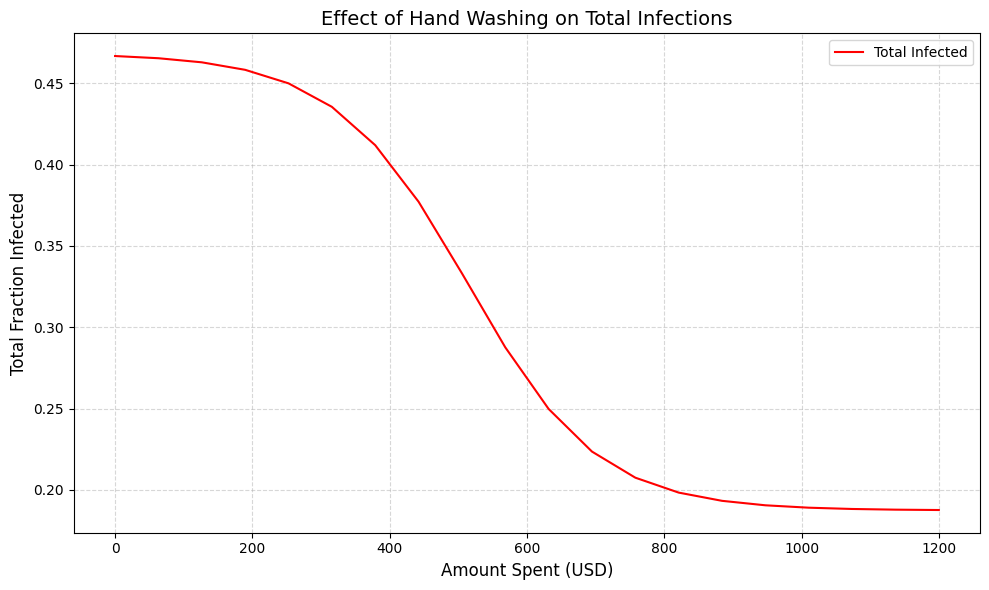

In [18]:
##=============================================================================================##
## Create the Array of Spending Amounts:                                                       ##
##=============================================================================================##

spending_array = np.linspace(0, 1200, 20)

##=============================================================================================##
## Run the Parameter Sweep:                                                                    ##
##=============================================================================================##

infected_sweep_hw = sweep_hand_washing(parameters_sir, spending_array)

##=============================================================================================##
## Graph the Results:                                                                          ##
##=============================================================================================##

ax = infected_sweep_hw.plot(
    kind    = 'line',
    y       = ['Total Infected'],
    x       = 'Spending Amount',
    color   = ['red'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Effect of Hand Washing on Total Infections", fontsize = 14)

ax.set_xlabel("Amount Spent (USD)", fontsize = 12)

ax.set_ylabel("Total Fraction Infected", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha=0.5)

plt.tight_layout()

# Display the plot:

plt.show()

Below 200 dollars, the campaign has little effect.  At 800 dollars it has a substantial effect, reducing total infections from more than 45% to about 20%.  Above 800 dollars, the additional benefit is small.  Not surprisingly, the results have a sigmoid shape: this is a direct result of the function we used to model the effects!

<center>$\rule$</center>

##<font size = 5> <b> 4.3 Optimization </b> </font>

Let's put it all together. With a fixed budget of \$1200, we have to
decide how many doses of vaccine to buy and how much to spend on the
hand-washing campaign.  Here are the parameters:

The fraction `budget/price_per_dose` might not be an integer. `int` is a
built-in function that converts numbers to integers, rounding down.  We'll sweep the range of possible doses:

In [ ]:
dose_array = np.arange(0,max_doses+1,1)
dose_array

Remember that `arange()` does not include the stop point (which here is 12): this is why we add 1 to `max_doses`.  Then we run the simulation for each element of `dose_array`:

In [19]:
##=============================================================================================##
## Define the Sweep Doses Function:                                                            ##
##=============================================================================================##

def sweep_doses(parameter_base, state_base, dose_array):

  num_students = 90
  budget = 1200
  price_per_dose = 100

  # Create an empty DataFrame to store the percent infected for each of the simulations:

  total_infected_series = pd.Series([],dtype=object)

  # Create a copy of the supplied base state so as not to overwrite any of its values:

  parameter_base_local = parameter_base.copy()

  state_base_local = state_base.copy()

  # Loop over the values in the supplied spending array for amount spent on campaign:

  for n_dose in dose_array:

    # Create the initial state based on the current level of spending:

    spending = budget - n_dose * price_per_dose

    initial_parameters = add_hand_washing(parameter_base_local, spending)

    # Create the initial state based on the current immunization percentage:

    fraction = n_dose / num_students

    initial_state = add_immunization(state_base_local, fraction)

    # Run the simulation with the current initial state:

    history = run_simulation(initial_parameters, initial_state, change_function)

    # Get the total infected fraction from the simulation:

    total_infected_fraction = total_infected(history)

    # Store the total infected fraction in the series:

    total_infected_series[n_dose] = total_infected_fraction

  # Organize the total infected series:

  total_infected_df = pd.DataFrame(total_infected_series)

  total_infected_df.columns = ['Total Infected']

  total_infected_df.index.name = 'Number of Doses'

  total_infected_df.reset_index(inplace = True)

  # Return the total infected series:

  return total_infected_df

For each number of doses, we compute the fraction of students we can
immunize, `fraction` and the remaining budget we can spend on the
campaign, `spending`. Then we run the simulation with those quantities
and store the number of infections.

The following figure shows the result.

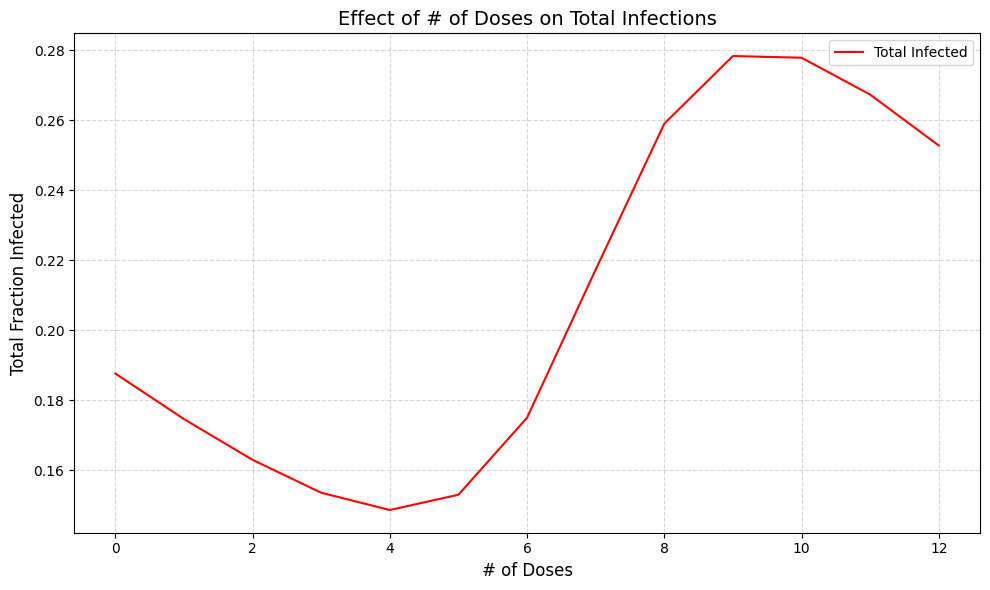

In [20]:
##=============================================================================================##
## Create the Array of Spending Amounts:                                                       ##
##=============================================================================================##

max_doses = 12

dose_array = np.arange(0, max_doses + 1, 1)

##=============================================================================================##
## Run the Parameter Sweep:                                                                    ##
##=============================================================================================##

dose_sweep = sweep_doses(parameters_sir, initial_state_sir, dose_array)

##=============================================================================================##
## Graph the Results:                                                                          ##
##=============================================================================================##

ax = dose_sweep.plot(
    kind    = 'line',
    y       = ['Total Infected'],
    x       = 'Number of Doses',
    color   = ['red'],
    figsize = (10, 6)
)

# Add titles and labels to the plot:

ax.set_title("Effect of # of Doses on Total Infections", fontsize = 14)

ax.set_xlabel("# of Doses", fontsize = 12)

ax.set_ylabel("Total Fraction Infected", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha=0.5)

plt.tight_layout()

# Display the plot:

plt.show()

If we buy no doses of vaccine and spend the entire budget on the campaign, the fraction infected is around 19%. At 4 doses, we have \$800 left for the campaign, and this is the optimal point that minimizes the number of students who get sick.

<br>

As we increase the number of doses, we have to cut campaign spending,
which turns out to make things worse. But interestingly, when we get
above 10 doses, the effect of herd immunity starts to kick in, and the
number of sick students goes down again.